In [1]:
import matplotlib.pyplot as plt
%matplotlib ipympl

# How to use (decorr)

## General usage

:mod:`noisefinder` allows the user to perform *noise projection*, or *decorrelation*, as we describe in the reference paper. Let's work out a minimal example.

In [9]:
import noisefinder
import numpy as np
import scipy.stats as st
import scipy.signal as sig

Generate three time series with known PSDs. The measured ones are included in the vectore `meas`, whereas `datares` is the residual, unknown to the algorithm, which we would like to retrieve as a result (its PSD).\
The main timeseries :math:`A` is correlated to :math:`B` and :math:`C` through the coefficients :math:`\alpha_i=19,0.1`, which we also want to retrieve.

In [10]:
datres = np.cumsum(st.norm.rvs(size=210000))+100*st.norm.rvs(size=210000)
datB = 0.5*np.cumsum(st.norm.rvs(size=210000))
datC = 1000*st.norm.rvs(size=210000)

alphaB = 19
alphaC = 0.10
datA = datres + alphaB*datB + alphaC*datC

datres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
datB_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
datC_true = lambda f: 1000*np.sqrt(2/10)*f**0
datA_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [datA,datB,datC]

#calculate welch for comparison
PSDfres,PSDvres = sig.welch(datres,fs=10,window='blackmanharris',nperseg=20000)
PSDfA,PSDvA = sig.welch(datA,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = sig.welch(datB,fs=10,window='blackmanharris',nperseg=20000)
PSDfC,PSDvC = sig.welch(datC,fs=10,window='blackmanharris',nperseg=20000)

We create an instance of :class:`noisefinder.CPSD_LPFmethod`, as we want to do it with the LPF frequency scheme, for this example.\
We evaluate the PSD quantiles, as we will use them later.

In [11]:
meas_LPFmethod = noisefinder.CPSD_LPFmethod(ts=[datA,datB,datC],fs=10,Tmax=2000,fmax=1)
meas_LPFmethod_PSDq = meas_LPFmethod.PSDquantiles_eval(cval=0.68)
meas_LPFmethod_PSDq_datA = meas_LPFmethod_PSDq[0,:,:]

Now, we perform noise projection / decorrelation, with :class:`noisefinder.noiseproj`, and get the residual confidence intervals with :meth:`get_noiseprojCI`.

In [5]:
# now decorrelate
meas_sfnp = noisefinder.noiseproj(meas_LPFmethod)
meas_PSDq_resid,meas_alpre,meas_alpim = meas_sfnp.get_noiseprojCI(cval=0.68)

Plot the residual ASD, comparing with the expected values.

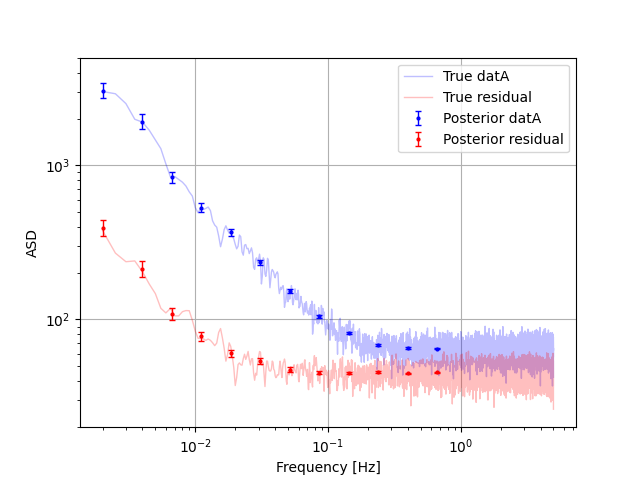

In [6]:
fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='True datA',c='b',alpha=0.25)
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='True residual',alpha=0.25)

tsidx = 0
ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_LPFmethod_PSDq_datA[1,:]),
            yerr = [np.sqrt(meas_LPFmethod_PSDq_datA[1,:])-np.sqrt(meas_LPFmethod_PSDq_datA[0,:]),
                    np.sqrt(meas_LPFmethod_PSDq_datA[2,:])-np.sqrt(meas_LPFmethod_PSDq_datA[1,:])],
            linestyle='',capsize=2,lw=1,c='b',fmt='.',markersize=4,label='Posterior datA')

ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_PSDq_resid[:,1]),
            yerr = [np.sqrt(meas_PSDq_resid[:,1])-np.sqrt(meas_PSDq_resid[:,0]),np.sqrt(meas_PSDq_resid[:,2])-np.sqrt(meas_PSDq_resid[:,1])],
            linestyle='',capsize=2,lw=1,c='r',fmt='.',markersize=4,label='Posterior residual')

ax.grid(); ax.legend(); ax.set_ylim(2e1,5e3);
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('ASD'); 
plt.show()

And plot the susceptibilities, with their expected values.

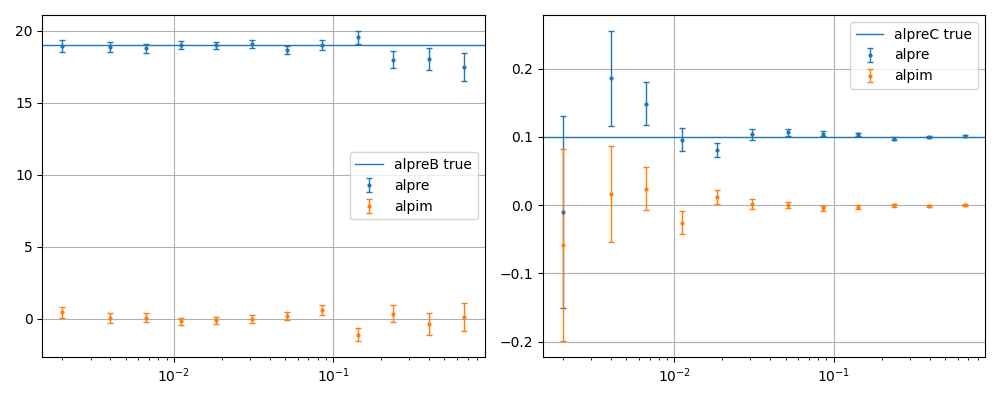

In [8]:
fig,ax=plt.subplots(1,2,figsize=(10,4),sharex=True)

tsidx = 0
ax[0].errorbar(meas_LPFmethod.freqs,
            meas_alpre[:,tsidx,1],
            yerr = [meas_alpre[:,tsidx,1]-meas_alpre[:,tsidx,0],meas_alpre[:,tsidx,2]-meas_alpre[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpre')
ax[0].axhline(19,c='C0',lw=1,label='alpreB true')
ax[0].errorbar(meas_LPFmethod.freqs,
            meas_alpim[:,tsidx,1],
            yerr = [meas_alpim[:,tsidx,1]-meas_alpim[:,tsidx,0],meas_alpim[:,tsidx,2]-meas_alpim[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpim')
ax[0].set_xscale('log'); ax[0].grid(); ax[0].legend()

tsidx = 1
ax[1].errorbar(meas_LPFmethod.freqs,
            meas_alpre[:,tsidx,1],
            yerr = [meas_alpre[:,tsidx,1]-meas_alpre[:,tsidx,0],meas_alpre[:,tsidx,2]-meas_alpre[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpre')
ax[1].axhline(0.1,c='C0',lw=1,label='alpreC true')
ax[1].errorbar(meas_LPFmethod.freqs,
            meas_alpim[:,tsidx,1],
            yerr = [meas_alpim[:,tsidx,1]-meas_alpim[:,tsidx,0],meas_alpim[:,tsidx,2]-meas_alpim[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpim')
ax[1].set_xscale('log'); ax[1].grid(); ax[1].legend()
fig.tight_layout()
plt.show()